In [ ]:
!pip install kaggle scipy numpy pandas matplotlib
import os, zipfile
import numpy as np
import pandas as pd
import gc, random
import scipy.sparse as sp
import matplotlib.pyplot as plt

In [ ]:
!pip install pyspark

from pyspark.sql import SparkSession
from pyspark import StorageLevel
spark = SparkSession.builder.master("local[*]").appName("AMDPageRankSpark").getOrCreate()

sc = spark.sparkContext

print("Spark version: ", spark.version)
!java -version

Spark version:  4.0.2
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


In [ ]:
os.environ['KAGGLE_USERNAME'] = "xxx"
os.environ['KAGGLE_KEY'] = "xxx"

!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
100% 1.95G/1.95G [00:23<00:00, 87.6MB/s]



In [ ]:
with zipfile.ZipFile("new-york-times-articles-comments-2020.zip", "r") as z:
    z.extractall("nyt_dataset")

for f in os.listdir("nyt_dataset"):
    print(f)

nyt-comments-part4.csv
nyt-comments-part2.csv
nyt-comments-part9.csv
nyt-comments-part7.csv
nyt-comments-part3.csv
nyt-comments-part6.csv
nyt-comments-part1.csv
nyt-comments-part5.csv
nyt-articles-2020.csv
train.csv
nyt-comments-2020.csv
nyt-comments-part0.csv
test.csv
nyt-comments-part8.csv


# Subsampling and preprocessing


In [ ]:
#print("COMMENTS")
#print(df_comments.shape)
#print(df_comments.columns.tolist())
#print(df_comments.head(2))

#print("\nARTICLES")
#print(df_articles.shape)
#print(df_articles.columns.tolist())
#print(df_articles.head(2))

SUBSAMPLE = True #False to use the entire dataset

SUBSAMPLE_USERS = 50000
CHUNK_SIZE = 100000

df_articles = pd.read_csv("nyt_dataset/nyt-articles-2020.csv", usecols=['uniqueID', 'section']).rename(columns={'uniqueID': 'articleID'})


chunks = []

for chunk in pd.read_csv(
    "nyt_dataset/nyt-comments-2020.csv",
    usecols=['userID', 'articleID','isAnonymous','status'],
    chunksize = CHUNK_SIZE,
    low_memory=False
):
  chunk = chunk[
      (chunk['status']=='approved') &
      (chunk['isAnonymous']==False)
  ][['userID', 'articleID']].dropna()
  chunks.append(chunk)

df_comments = pd.concat(chunks, ignore_index=True)
df_comments = df_comments.drop_duplicates(subset=['userID', 'articleID'])
del chunks
gc.collect()

if SUBSAMPLE:
  random.seed(42)
  all_users = df_comments['userID'].unique().tolist()
  sampled_users = set(random.sample(all_users, min(SUBSAMPLE_USERS, len(all_users))))
  df_comments = df_comments[df_comments['userID'].isin(sampled_users)]

df = df_comments.merge(df_articles, on='articleID', how='left')
df['section'] = df['section'].fillna('Unknown')
del df_comments, df_articles
gc.collect()

print(f"Comments: {len(df)}")
print(f"Unique users: {df['userID'].nunique()}")
print(f"Unique articles: {df['articleID'].nunique()}")
print(f"Section: {df['section'].value_counts().head(10)}")


In [ ]:
print("Missing value per column: ")
print(df[['userID', 'articleID', 'section']].isna().sum())

df = df.dropna(subset=['userID', 'articleID'])

print(f"\nNumber of rows after removing NaN: {len(df)}")

Missing value per column: 
userID       0
articleID    0
section      0
dtype: int64

Number of rows after removing NaN: 435901


Comments per article: 
count    14928.000000
mean        29.200228
std         46.751011
min          1.000000
25%          3.000000
50%         11.000000
75%         32.000000
max        712.000000
dtype: float64


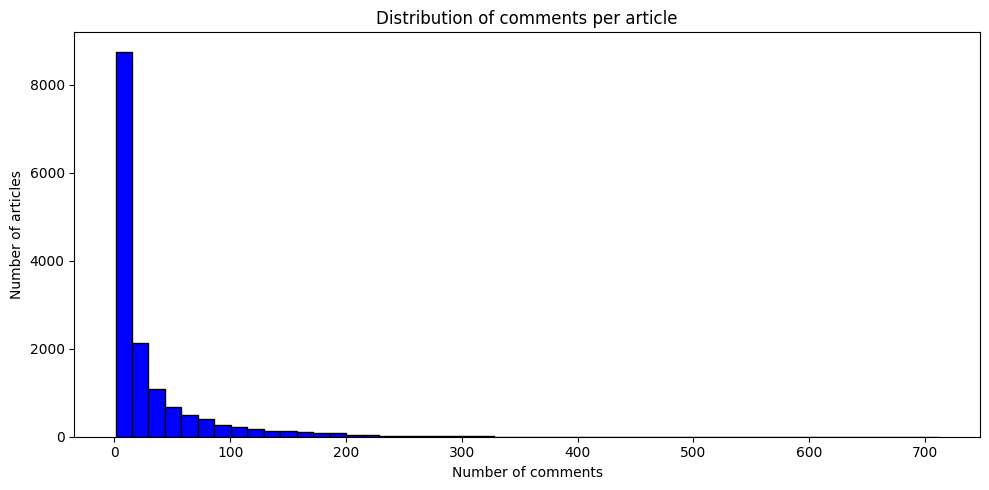

In [ ]:
comments_per_article = df.groupby('articleID').size()
print("Comments per article: ")
print(comments_per_article.describe())

plt.figure(figsize=(10,5))
plt.hist(comments_per_article, bins=50, color='blue', edgecolor='black')
plt.xlabel('Number of comments')
plt.ylabel('Number of articles')
plt.title('Distribution of comments per article')
plt.tight_layout()
plt.show()

Articles per user: 
count    50000.000000
mean         8.718020
std         38.216661
min          1.000000
25%          1.000000
50%          1.000000
75%          4.000000
max       2069.000000
dtype: float64


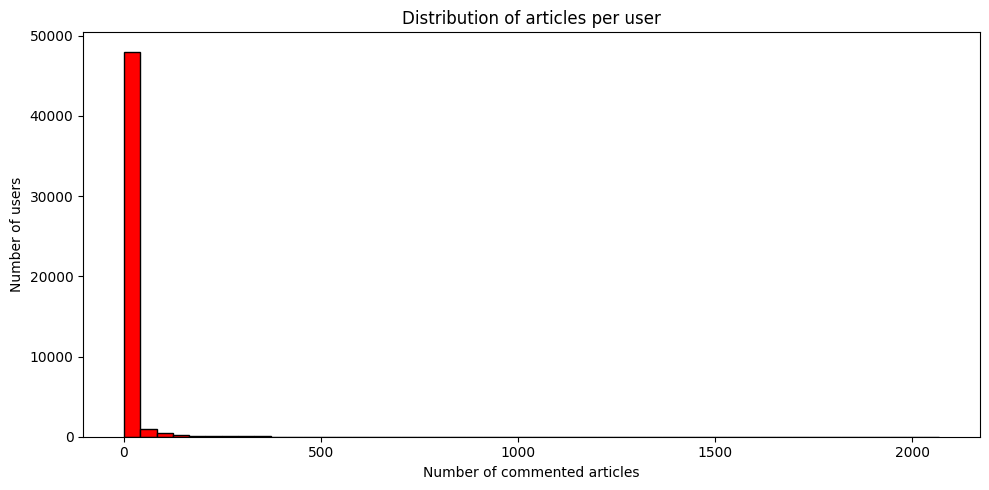

In [ ]:
article_per_user = df.groupby('userID').size()
print("Articles per user: ")
print(article_per_user.describe())

plt.figure(figsize=(10,5))
plt.hist(article_per_user, bins=50, color='red', edgecolor='black')
plt.xlabel('Number of commented articles')
plt.ylabel('Number of users')
plt.title('Distribution of articles per user')
plt.tight_layout()
plt.show()

# Graph creation


In [ ]:
from itertools import combinations

MAX_USERS_PER_ARTICLE = 200

unique_users = df['userID'].unique()
user2idx = {u: i for i, u in enumerate(unique_users)}
N = len(unique_users)
print(f"Number of nodes: {N}")

CHUNK = 2000000
A = sp.csr_matrix((N, N), dtype=np.float32)
rows_buf, cols_buf = [], []

def build_add_chunk(rows_buf, cols_buf, A, N):
  data = np.ones(len(rows_buf), dtype=np.float32)
  chunk_mat = sp.csr_matrix((data, (np.array(rows_buf, dtype=np.int32), np.array(cols_buf, dtype=np.int32))), shape=(N,N))
  return A + chunk_mat

for article_id, group in df.groupby('articleID'):
  users = group['userID'].tolist()

  if len(users) > MAX_USERS_PER_ARTICLE:
    users = users[:MAX_USERS_PER_ARTICLE]

  if len(users) < 2:
    continue

  for u1, u2 in combinations(users, 2):
    i = user2idx[u1]
    j = user2idx[u2]

    rows_buf.append(i); cols_buf.append(j)
    rows_buf.append(j); cols_buf.append(i)

    if len(rows_buf) >= CHUNK:
      A = build_add_chunk(rows_buf, cols_buf, A, N)
      rows_buf.clear()
      cols_buf.clear()

if rows_buf:
  A = build_add_chunk(rows_buf, cols_buf, A, N)
del rows_buf, cols_buf

A = A.astype(bool).astype(np.float32)
degrees = np.array(A.sum(axis=1)).flatten()
isolated = (degrees == 0).sum()

print(f"Number of edges: {A.nnz:}")
print(f"Density: {A.nnz /(N*N):.6f}")
print(f"Isolated users: {isolated}")
print(f"Avg degree: {degrees.mean():.2f}")
print(f"Max degree: {degrees.max():.0f}")

Number of nodes: 50000
Number of edges: 21086580
Density: 0.008435
Isolated users: 1339
Avg degree: 421.73
Max degree: 23282


# PageRank


In [ ]:
import time

def build_transition_matrix(A):

  col_sums = np.array(A.sum(axis=0)).flatten()
  dead_end = (col_sums == 0)
  col_sums[dead_end] = 1

  M = A / col_sums
  return M, dead_end

def pagerank(A, beta=0.85, max_iter=100, tol=1e-6, verbose=True):
  N = A.shape[0]
  M, dead_end = build_transition_matrix(A)

  r = np.ones(N, dtype=np.float64) / N

  history = []

  for iteration in range(max_iter):
    dead_end_sum = r[dead_end].sum()

    r_new = (beta * M.dot(r)
             + beta * dead_end_sum/N
             + (1-beta)/N)
    diff = np.abs(r_new - r).sum()
    history.append(diff)
    r = r_new

    if diff < tol:
      if verbose:
        print(f"Convergence achieved after {iteration+1} iterations")
      break
  else:
    if verbose:
      print(f"Convergence not achieved after {max_iter} iterations")

  return r, history


In [ ]:
start_pr = time.time()
pr, pr_history = pagerank(A, beta=0.85)
end_pr = time.time()

print(f"Execution time of PageRank: {end_pr-start_pr:.2f}s")
print(f"Sum of scores: {pr.sum():.6f}")

idx2user = {i: u for u, i in user2idx.items()}
top20_pr = pr.argsort()[::-1][:20]

print("\nBest 20 users ordered by score (PageRank): ")
print(f"{'Rank':<6} {'UserID':<15} {'Score':<12} {'Degree':<10}")

for rank, idk in enumerate(top20_pr, 1):
  user = idx2user[idk]
  score = pr[idk]
  degree = int(degrees[idk])
  print(f"{rank:<6} {user:<15} {score:<12.6f} {degree:<10}")

Convergence achieved after 37 iterations
Execution time of PageRank: 6.63s
Sum of scores: 1.000000

Best 20 users ordered by score (PageRank): 
Rank   UserID          Score        Degree    
1      61986282        0.001118     23282     
2      2073520         0.000912     21242     
3      51905269        0.000901     18879     
4      75716722        0.000779     17746     
5      33668404        0.000762     17653     
6      80110445        0.000748     17418     
7      75215278        0.000713     15950     
8      51415176        0.000682     16552     
9      37617930        0.000672     16595     
10     62938502        0.000658     15959     
11     80370332        0.000653     15038     
12     48376006        0.000650     15653     
13     51087612        0.000636     14741     
14     23255351        0.000623     12440     
15     57353517        0.000612     14986     
16     87637841        0.000607     11871     
17     73444633        0.000595     14186     
18     695

# PageRank with Spark

In [ ]:
cx = A.tocoo()
edges_rdd = sc.parallelize(zip(cx.row.tolist(), cx.col.tolist()))
del cx

adjacency = (
    edges_rdd
    .distinct()
    .groupByKey()
    .mapValues(list)
    .cache()
)

In [ ]:
def propagate_contribution(partition):
  for src, (neighbors, rank) in partition:
    if neighbors:
      contribution = rank / len(neighbors)
      for dst in neighbors:
        yield (dst, contribution)

def pagerank_spark(adjacency, rank_rdd, N, sc, beta=0.85, max_iter=100, tol=1e-6, verbose=True):

    num_partitions = max(sc.defaultParallelism * 2, 8)

    N_b = sc.broadcast(N)
    beta_b = sc.broadcast(beta)

    all_node_set = set(range(N))
    nodes_with_edges = set(adjacency.keys().distinct().collect())
    dead_end = all_node_set - nodes_with_edges
    dead_end_b = sc.broadcast(dead_end)

    adjacency = adjacency.partitionBy(num_partitions).persist(StorageLevel.MEMORY_AND_DISK)
    adjacency.count()
    
    all_nodes = (
        sc.parallelize(range(N), num_partitions)
        .map(lambda x: (x, None))
        .partitionBy(num_partitions)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    rank_rdd = rank_rdd.partitionBy(num_partitions).persist(StorageLevel.MEMORY_AND_DISK)

    history = []

    for iteration in range(max_iter):

        if verbose:
            print(f"Iteration {iteration + 1}...")

        dead_end_sum = rank_rdd.filter(lambda x: x[0] in dead_end_b.value).values().sum()
        dead_end_contrib = beta_b.value * dead_end_sum / N_b.value
        teleport_contrib = (1.0 - beta_b.value) / N_b.value
        base_rank = dead_end_contrib + teleport_contrib

        new_rank_rdd = (
            adjacency
            .join(rank_rdd, num_partitions)
            .mapPartitions(propagate_contribution)
            .combineByKey(lambda v:v,
                          lambda acc, v : acc + v,
                          lambda a,b : a + b,
                          num_partitions)
            .mapValues(lambda r: beta_b.value * r + base_rank)
            )

        new_rank_rdd = (
            all_nodes
            .leftOuterJoin(new_rank_rdd, num_partitions)
            .mapValues(lambda x: x[1] if x[1] is not None else base_rank)
            .partitionBy(num_partitions)
            .persist(StorageLevel.MEMORY_AND_DISK)
        )


        diff = (rank_rdd
                .join(new_rank_rdd, num_partitions)
                .map(lambda x: abs(x[1][0] - x[1][1]))
                .sum())

        history.append(diff)
        old_rank = rank_rdd
        rank_rdd = new_rank_rdd
        old_rank.unpersist()

        if diff < tol:
            if verbose:
                print(f"Convergence achieved after {iteration + 1} iterations")
            break
    else:
        if verbose:
            print(f"Convergence not achieved after {max_iter} iterations")

    dead_end_b.unpersist()
    N_b.unpersist()
    beta_b.unpersist()

    return rank_rdd, history


In [18]:
rank_init = sc.parallelize([(i, 1.0 / N) for i in range(N)])

start_spark = time.time()
pr_spark, pr_spark_history = pagerank_spark(adjacency, rank_init, N, sc, beta=0.85)
end_spark = time.time()
print(f"Execution time of PageRank_Spark: {end_spark-start_spark:.2f}s")
print(f"Sum of scores: {pr_spark.values().sum():.6f}")

top20_spark = pr_spark.sortBy(lambda x: x[1], ascending=False).take(20)
print("\nBest 20 users ordered by score (PageRank with Spark): ")
print(f"{'Rank':<6} {'UserID':<15} {'Score':<12} {'Degree':<10}")

for rank, (idk, score) in enumerate(top20_spark, 1):
  user = idx2user[idk]
  degree = int(degrees[idk])
  print(f"{rank:<6} {user:<15} {score:<12.6f} {degree:<10}")

Iteration 1...
Iteration 2...
Iteration 3...
Iteration 4...
Iteration 5...
Iteration 6...
Iteration 7...
Iteration 8...
Iteration 9...
Iteration 10...
Iteration 11...
Iteration 12...
Iteration 13...
Iteration 14...
Iteration 15...
Iteration 16...
Iteration 17...
Iteration 18...
Iteration 19...
Iteration 20...
Iteration 21...
Iteration 22...
Iteration 23...
Iteration 24...
Iteration 25...
Iteration 26...
Iteration 27...
Iteration 28...
Iteration 29...
Iteration 30...
Iteration 31...
Iteration 32...
Iteration 33...
Iteration 34...
Iteration 35...
Iteration 36...
Iteration 37...
Convergence achieved after 37 iterations
Execution time of PageRank_Spark: 1497.59s
Sum of scores: 1.000000

Best 20 users ordered by score (PageRank with Spark): 
Rank   UserID          Score        Degree    
1      61986282        0.001118     23282     
2      2073520         0.000912     21242     
3      51905269        0.000901     18879     
4      75716722        0.000779     17746     
5      33668404   

Execution time:
PageRank: 6.63s
PageRank with Spark: 1497.59s


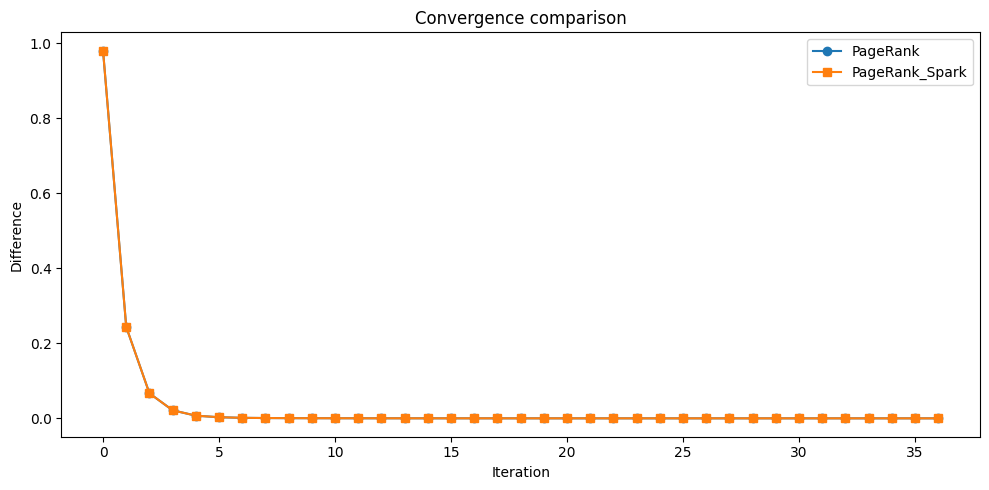


Rank   PR UserID            PR Score       PR_Spark UserID      PR_Spark Score Same?
------------------------------------------------------------------------------------------
1      61986282             0.001118       61986282             0.001118       ✓
2      2073520              0.000912       2073520              0.000912       ✓
3      51905269             0.000901       51905269             0.000901       ✓
4      75716722             0.000779       75716722             0.000779       ✓
5      33668404             0.000762       33668404             0.000762       ✓
6      80110445             0.000748       80110445             0.000748       ✓
7      75215278             0.000713       75215278             0.000713       ✓
8      51415176             0.000682       51415176             0.000682       ✓
9      37617930             0.000672       37617930             0.000672       ✓
10     62938502             0.000658       62938502             0.000658       ✓
11     803703

In [19]:
print("Execution time:")
print(f"PageRank: {end_pr-start_pr:.2f}s")
print(f"PageRank with Spark: {end_spark-start_spark:.2f}s")

plt.figure(figsize=(10,5))
plt.plot(pr_history, marker="o", label='PageRank')
plt.plot(pr_spark_history, marker="s", label='PageRank_Spark')
plt.xlabel('Iteration')
plt.ylabel('Difference')
plt.title('Convergence comparison')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n{'Rank':<6} {'PR UserID':<20} {'PR Score':<14} {'PR_Spark UserID':<20} {'PR_Spark Score':<14} {'Same?'}")
print("-" * 90)
for rank, (ni, si) in enumerate(zip(pr.argsort()[::-1][:20], [idk for idk, _ in pr_spark.sortBy(lambda x: x[1], ascending=False).take(20)]), 1):
    n_user = idx2user[ni]
    s_user = idx2user[si]
    n_score = pr[ni]
    s_score = dict(top20_spark)[si]
    same = "✓" if n_user == s_user else "✗"
    print(f"{rank:<6} {n_user:<20} {n_score:<14.6f} {s_user:<20} {s_score:<14.6f} {same}")


# Topic - Sentitive PageRank


In [22]:
topics = ['Opinion', 'U.S.', 'World']

topic_users = {}

for topic in topics:
  user_in_topic = set(df[df['section']==topic]['userID'].unique())
  topic_users[topic] = {user2idx[u] for u in user_in_topic if u in user2idx}
  print(f"{topic}: {len(topic_users[topic])} users")

def topic_sensitive_pr(A, topic_nodes, beta=0.85, max_iter=100, tol=1e-6, verbose=True):
  N = A.shape[0]
  M, dead_end = build_transition_matrix(A)

  teleport = np.zeros(N, dtype=np.float64)
  teleport[list(topic_nodes)] = 1.0 / len(topic_nodes)

  r = np.ones(N, dtype=np.float64) / N
  history = []

  for iteration in range(max_iter):
    dead_end_sum = r[dead_end].sum()

    r_new = (beta * M.dot(r)
            + beta * dead_end_sum * teleport
            + (1 - beta) * teleport)

    diff = np.abs(r_new-r).sum()
    history.append(diff)
    r = r_new

    if diff < tol:
      if verbose:
        print(f"Convergence achieved after {iteration + 1} iterations")
        break
  else:
    if verbose:
      print(f"Convergence not achieved after {max_iter} iterations")

  return r, history

tspr_result = {}

for topic in topics:
  print(f"\nTopic: {topic}")
  start_tspr = time.time()
  tspr, history_tspr = topic_sensitive_pr(A, topic_users[topic], beta=0.85)
  end_tspr = time.time()

  print(f"Execution time of PageRank_Spark: {end_tspr-start_tspr:.2f}s")
  print(f"Sum of scores: {tspr.sum():.6f}")
  tspr_result[topic] = (tspr, history_tspr)

  print(f"Best 20 users ordered by score for '{topic}' (Topic-Sensitive PageRank): ")
  print(f"{'Rank':<6} {'UserID':<15} {'Score':<12} {'Degree':<10}")
  top20_tspr = tspr.argsort()[::-1][:20]
  for rank, idk in enumerate(top20_tspr, 1):
    user = idx2user[idk]
    score = tspr[idk]
    degree = int(degrees[idk])
    print(f"{rank:<6} {user:<15} {score:<12.6f} {degree:<10}")
  print("\n")

Opinion: 24460 users
U.S.: 17192 users
World: 7441 users

Topic: Opinion
Convergence achieved after 63 iterations
Execution time of PageRank_Spark: 11.43s
Sum of scores: 1.000000
Best 20 users ordered by score for 'Opinion' (Topic-Sensitive PageRank): 
Rank   UserID          Score        Degree    
1      61986282        0.001227     23282     
2      2073520         0.001082     21242     
3      51905269        0.000878     18879     
4      37617930        0.000839     16595     
5      80110445        0.000839     17418     
6      33668404        0.000822     17653     
7      75716722        0.000816     17746     
8      75215278        0.000782     15950     
9      51415176        0.000769     16552     
10     62938502        0.000766     15959     
11     57353517        0.000743     14986     
12     51087612        0.000730     14741     
13     80370332        0.000680     15038     
14     48376006        0.000676     15653     
15     62161655        0.000645     13844 

In [38]:
print(f"{'Rank':<6} {'UserID':<15} {'Score':<12} {'PR Rank':<10}", end="")
for topic in topics:
  print(f"{'TSPR_'+ topic:<20}", end="")
print()
print("-" * 100)

for rank, ni in enumerate(top20_pr, 1):
  user = idx2user[ni]
  pr_score = pr[ni]
  print(f"{rank:<6} {user:<15} {pr_score:<14.6f} {rank:<10}", end="")

  for topic in topics:
    tspr = tspr_result[topic][0]
    tspr_ranking = list(tspr.argsort()[::-1])
    tspr_rank = tspr_ranking.index(ni) + 1
    print(f"{tspr_rank:<20}", end="")
  print()

Rank   UserID          Score        PR Rank   TSPR_Opinion        TSPR_U.S.           TSPR_World          
----------------------------------------------------------------------------------------------------
1      61986282        0.001118       1         1                   1                   1                   
2      2073520         0.000912       2         2                   2                   2                   
3      51905269        0.000901       3         3                   3                   3                   
4      75716722        0.000779       4         7                   5                   4                   
5      33668404        0.000762       5         6                   4                   5                   
6      80110445        0.000748       6         5                   6                   6                   
7      75215278        0.000713       7         8                   9                   11                  
8      51415176        0.0006